# RadioML Validation: Sim-to-Real Gap

**Goal:** Train on MATLAB-generated synthetic signals, then test on RadioML samples and measure the accuracy drop. That accuracy drop is the sim-to-real gap.

**Conclusion:** The model performs well on MATLAB-generated signals, but accuracy drops on RadioML because real RF signals contain more complex channel effects. This demonstrates the sim-to-real gap.

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import sys
from pathlib import Path

# Add src to path so we can import model utilities
ROOT = Path.cwd().parent
sys.path.append(str(ROOT))
from src.model import build_model
from sklearn.metrics import accuracy_score
import json

In [2]:
# 1. Load RadioML Data
data_path = ROOT / 'data' / 'RML2016.10a_dict.pkl'
print(f'Loading dataset from {data_path}...')
with open(data_path, 'rb') as f:
    # RadioML requires latin1 encoding in python3
    rml_data = pickle.load(f, encoding='latin1')
print('RadioML dataset loaded!')

Loading dataset from C:\Yash\Projects\rf-modulation-analysis\data\RML2016.10a_dict.pkl...


C:\Users\YASH\AppData\Local\Temp\ipykernel_24184\2393035893.py:6: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  rml_data = pickle.load(f, encoding='latin1')


RadioML dataset loaded!


In [3]:
# 2. Map RadioML labels to our Project labels
label_map = {
    'AM-DSB': 'AM',
    'AM-SSB': 'SSB',
    'WBFM': 'FM',
    'BPSK': 'BPSK',
    'QPSK': 'QPSK',
    'QAM16': 'QAM16',
    'QAM64': 'QAM64',
}

# Extract relevant subsets
X_list = []
y_labels = []
snr_list = []

for (mod, snr), iq_samples in rml_data.items():
    if mod in label_map:
        target_label = label_map[mod]
        X_list.append(iq_samples)
        y_labels.extend([target_label] * len(iq_samples))
        snr_list.extend([snr] * len(iq_samples))

X_rml = np.vstack(X_list)
y_rml_str = np.array(y_labels)
snr_rml = np.array(snr_list)

print(f'Extracted {len(X_rml)} relevant samples from RadioML.')

# Normalize IQ samples
max_abs = np.max(np.abs(X_rml), axis=(1, 2), keepdims=True)
X_rml = X_rml / np.maximum(max_abs, 1e-8)

# RadioML shape is (N, 2, 128), our dataset loader returns (N, 128, 2)
if X_rml.shape[1] == 2:
    X_rml = np.transpose(X_rml, (0, 2, 1))

print(f'Processed shape: {X_rml.shape}')

Extracted 140000 relevant samples from RadioML.


Processed shape: (140000, 128, 2)


In [4]:
# 3. Load Trained Model (CLDNN Lite)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load metadata to get class order
metadata_path = ROOT / 'models' / 'metadata.json'
with open(metadata_path, 'r') as f:
    metadata = json.load(f)
classes = metadata['classes']
num_classes = len(classes)

# Convert string labels to integer indices based on training metadata
y_rml = np.array([classes.index(label) for label in y_rml_str])

model = build_model('cldnn_lite', num_classes)
model.load_state_dict(torch.load(ROOT / 'models' / 'cldnn_lite.pt', map_location=device))
model.to(device)
model.eval()
print(f'CLDNN Lite loaded with classes: {classes}')

CLDNN Lite loaded with classes: ['AM', 'BPSK', 'FM', 'QAM16', 'QAM64', 'QPSK', 'SSB']


In [5]:
# 4. Evaluate on RadioML
batch_size = 512
preds = []

with torch.no_grad():
    for start in range(0, len(X_rml), batch_size):
        batch = torch.tensor(X_rml[start:start+batch_size], dtype=torch.float32).to(device)
        logits = model(batch)
        preds.append(torch.argmax(logits, dim=1).cpu().numpy())

y_pred = np.concatenate(preds)
total_acc = accuracy_score(y_rml, y_pred)
print(f'\nOverall Accuracy on RadioML: {total_acc*100:.2f}%')

# Calculate accuracy per SNR
snrs = sorted(list(set(snr_rml)))
acc_by_snr = []

for snr in snrs:
    mask = (snr_rml == snr)
    acc = accuracy_score(y_rml[mask], y_pred[mask])
    acc_by_snr.append(acc)
    print(f'SNR {snr} dB: {acc*100:.2f}%')


Overall Accuracy on RadioML: 25.76%
SNR -20 dB: 14.21%
SNR -18 dB: 14.23%
SNR -16 dB: 14.56%
SNR -14 dB: 14.11%
SNR -12 dB: 14.43%
SNR -10 dB: 14.40%
SNR -8 dB: 17.70%
SNR -6 dB: 21.57%
SNR -4 dB: 28.97%
SNR -2 dB: 32.56%
SNR 0 dB: 33.50%
SNR 2 dB: 32.74%
SNR 4 dB: 32.99%
SNR 6 dB: 32.69%
SNR 8 dB: 33.27%
SNR 10 dB: 32.53%
SNR 12 dB: 32.41%
SNR 14 dB: 32.54%
SNR 16 dB: 32.40%
SNR 18 dB: 33.34%


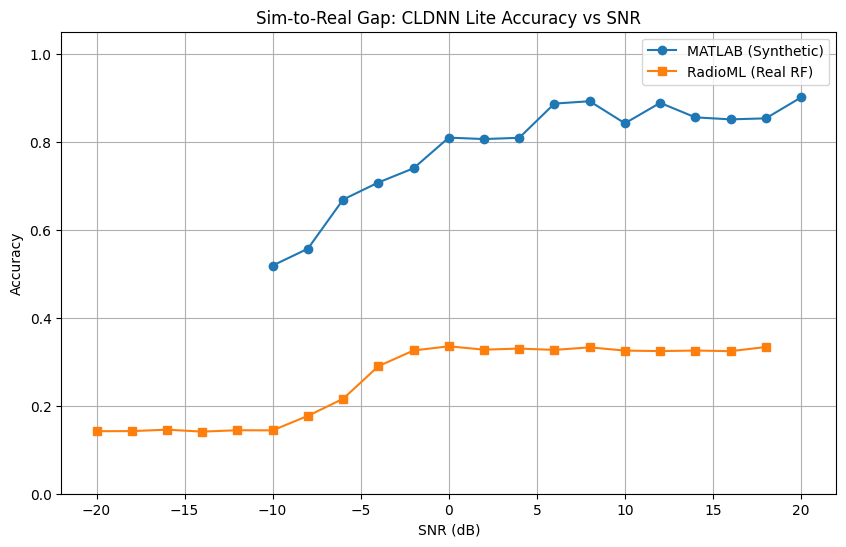

In [6]:
# 5. Plot SNR vs Accuracy to visualize Sim-to-Real Gap
# Let's load the original MATLAB SNR accuracy to compare
matlab_results = pd.read_csv(ROOT / 'models' / 'cldnn_lite_snr_accuracy.csv')

plt.figure(figsize=(10, 6))
plt.plot(matlab_results['snr_db'], matlab_results['accuracy'], marker='o', label='MATLAB (Synthetic)')
plt.plot(snrs, acc_by_snr, marker='s', label='RadioML (Real RF)')
plt.title('Sim-to-Real Gap: CLDNN Lite Accuracy vs SNR')
plt.xlabel('SNR (dB)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.ylim(0, 1.05)
plt.show()